# Reading tree-ring data with dplPy

This notebook provides a tour through the capababilities of `dplpy.readers()`, which reads Tucson format `.rwl` files (and `.csv`)
into a Pandas `DataFrame`.  This dataframe has one column for each measurement series, indexed by year.  The full description of `readers` can be found in the documentation here: https://opendendro.github.io/dplPy/reference/io/#readers and the User Guide here: https://opendendro.github.io/dplPy/guide/reading-writing-data/#ring-width-files-with-readers.

This notebook uses the sample files shipped in `../tests/data/rwl/` and `../tests/data/csv/`, so it runs as-is from the `notebooks/` folder of the
repository.

First, we'll import dplPy:

In [24]:
import dplpy as dpl
import matplotlib.pyplot as plt

dpl.__version__

'0.6.0'

In order to be able to use this notebook 'out of the box', set the paths to where the Tucson `.rwl` and the `.csv` files live.  These files reflect a range of different data, including several with known formating errors used to test the robustness of `readers.py`.  

In [25]:
# Sample data shipped with the repo, relative to the notebooks/ folder.
RWL = "../tests/data/rwl/"
CSV = "../tests/data/csv/"

### The Basics

At its most simple, you can pass a filename (and path) and get back a year-indexed `DataFrame` with one column per series.  We'll call `dpl.stats` as well, to give us a quick look at the data that is now in our workspace.  

In [26]:
data = dpl.readers(RWL + "ca533.rwl")
dpl.stats(data)

ca533.rwl successfully extracted as rwl file with 34 series covering the period from 626 to 1983


,series,first,last,year,mean,median,stdev,skew,kurtosis,gini,ar1
1,CAM011,1530,1983,454,0.440,0.40,0.222,1.029,1.102,0.273,0.696
2,CAM021,1433,1983,551,0.424,0.40,0.185,0.946,1.110,0.237,0.701
3,CAM031,1356,1983,628,0.349,0.29,0.214,0.690,-0.366,0.341,0.808
4,CAM032,1435,1983,549,0.293,0.26,0.163,0.717,0.159,0.309,0.661
5,CAM041,1683,1983,301,0.526,0.53,0.223,0.488,0.098,0.238,0.690
6,CAM042,1538,1983,446,0.439,0.36,0.348,3.678,17.713,0.324,0.880
7,CAM051,1247,1983,737,0.273,0.25,0.140,1.836,6.678,0.262,0.705
8,CAM061,1357,1983,627,0.462,0.47,0.202,-0.111,-0.223,0.247,0.509
9,CAM062,1525,1983,459,0.442,0.45,0.188,-0.266,-0.196,0.240,0.529
10,CAM071,1037,1983,947,0.249,0.25,0.109,0.027,0.022,0.247,0.577


You should see a success message from `dpl.readers`, indicating the file type, number of series, and the full time span of the data. 

As `data` is a Pandas `DataFrame`, we can append a [`.plot`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html) method to it and use `plt.` methods from Matplotlib to add axes and a title:

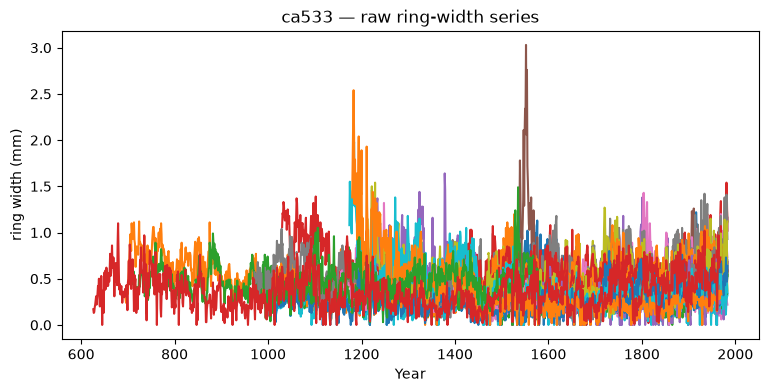

In [27]:
data.plot(legend=False, figsize=(9, 4))
plt.xlabel("Year")
plt.ylabel("ring width (mm)")
plt.title("ca533 — raw ring-width series")
plt.show()

We can see the raw ring widths in units of mm arrayed through time.  We can also use append other methods from Pandas.  For instance, we can get a quick sample depth plot by first counting the number of non-NaN values in each row using [`.count`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.count.html), then using `.plot` again to display these:

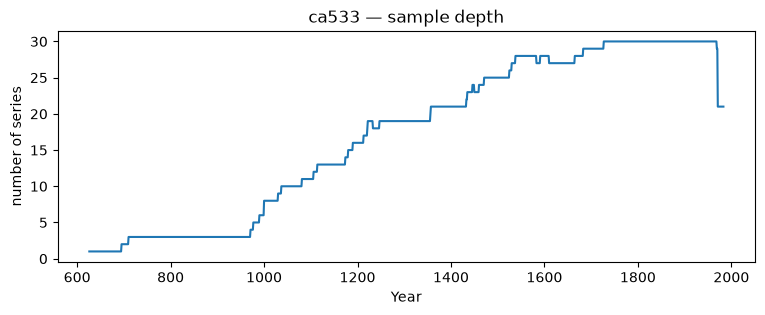

In [28]:
data.count(axis=1).plot(figsize=(9, 3))
plt.xlabel("Year")
plt.ylabel("number of series")
plt.title("ca533 — sample depth")
plt.show()

### Headers are detected automatically and read attributes are recorded

dplPy automatically identifies where the data rows actually start and records how many header lines it skipped onin `df.attrs`. The `.attrs` is once again a feature of Pandas (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.attrs.html) that can store attributes for the dataset, so that this information is carried along throughout your script.  `readers` uses `.attrs` to store anything unusual during the import process as well as metadata:

In [29]:
tx = dpl.readers(RWL + "tx042.rwl")
print("header lines skipped:", tx.attrs["dplpy_header_lines_skipped"])


tx042.rwl successfully extracted as rwl file with 95 series covering the period from 1473 to 1992 (auto-detected 3 header lines)
header lines skipped: 3


### Metadata in the header is identified and saved

The site and sample metadata is parsed as best as possible from the header by `dpl.readers` and is saved into `df.attrs["dplpy_metadata"]`.  Alternatively we provide `dpl.metadata()` which allows you to simply extract the metadata into a Python `dict` structure:

In [30]:
meta = dpl.metadata(RWL + "tx042.rwl")
meta

{'site_id': 'BSC',
 'site_name': 'Big Bend National Park incl. Camp Springs',
 'species_code': 'PSME',
 'species_name': 'Douglas Fir',
 'country_region': 'Texas',
 'elevation_m': 2057,
 'latitude': 29.25,
 'longitude': -103.3,
 'first_year': 1473,
 'last_year': 1992,
 'investigators': 'Brewster  E.Cook  N.Montagu',
 'n_header_lines': 3,
 'header_raw': ['BSC    1 Big Bend National Park incl. Camp Springs           PSME               ',
  'BSC    2 Texas        Douglas Fir       2057M  2915-10318    __    1473 1992    ',
  'BSC    3 Brewster  E.Cook  N.Montagu                                            '],
 'hemisphere_verified': True}

Values in `meta` (or any `dict`) can then be extracted or printed to the screen (or added to a plot) by using square brackets and the name of the field (called the 'key' in Python) in quotation marks:

In [31]:
print(meta["site_name"], "|", meta["species_code"], "-", meta["species_name"])

Big Bend National Park incl. Camp Springs | PSME - Douglas Fir


### Data-quality warnings and heads-up

`readers` reads the file but flags spots worth a human's examination. For instance, a short interior gap (a missing year inside a series not indicated by a negative number), or characters past the last data column (indicating a possibly truncated value). Once again, this information is stored in `df.attrs`:

In [32]:
wa = dpl.readers(RWL + "wa082.rwl")
wa.attrs["dplpy_interior_gaps"]

wa082.rwl successfully extracted as rwl file with 23 series covering the period from 1698 to 1983 (auto-detected 3 header lines), with 1 unreadable value set to NaN
  heads-up: 1 short interior gap (a blank year between measured years -- possibly a dropped value) in 1 series:
    712011: 1900


/Users/kja/projects/opendendro/dplPy/src/dplpy/readers.py:1787: UserWarning: 1 anomalous negative value(s) (not the -9999 stop marker) were set to NaN [712011@1900]
  warnings.warn(


[{'series': '712011',
  'gap_years': [1900],
  'short_gap_years': [1900],
  'max_run': 1}]

### Reading directly from the ITRDB

`readers` allows you to directly read Tucson formatted tree-ring data from a URL, including from the ITRDB.  In the example below, a *Pinus echinata* site from Oklahoma collected by Dave Stahle is fetched from the ITRDB, and `readers` warns the user that there is a likely formatting error that should be examined:

In [33]:
ok = dpl.readers("https://www.ncei.noaa.gov/pub/data/paleo/treering/measurements/northamerica/usa/ok049.rwl")


ok049.rwl successfully extracted as rwl file with 443 series covering the period from 1744 to 2020 (auto-detected 3 header lines)
  heads-up: 1 row had characters beyond the last data column (col 72) that were not parsed -- check for a truncated value:
    LIN152A 1839: read '303', ignored '5'  (looks like a split value)
  heads-up: 1 short interior gap (a blank year between measured years -- possibly a dropped value) in 1 series:
    LIN01A: 1939


### Duplicate IDs merged from separate segments

When a series ID appears more than once but do not have overlapping years of data, `readers` mimics dplR and joins them into a single series and reports the merge to the user.  The idea of this default is that duplicate ID series that do not overlap in time are likely to reflect a single sample that needed to be measured in pieces (e.g due to damage, compression wood, etc.).  However, if this is not the case, you can change this default behavior by setting `join=False`:

In [34]:
ca = dpl.readers(RWL + "ca667.rwl")


/Users/kja/projects/opendendro/dplPy/src/dplpy/readers.py:1866: UserWarning: Series ST850A had a duplicate ID in separate blocks with no overlapping years (joined into one series).
  warnings.warn("Series " + ids + " had a duplicate ID in separate blocks "


ca667.rwl successfully extracted as rwl file with 310 series covering the period from -2649 to 2005 (auto-detected 3 header lines)
  1 series combined from non-overlapping duplicate IDs (merged segments):
    ST850A: 2 segments spanning -662 to 453


Setting `join=False` will result in series with duplicate IDs being imported as separate series and renamed by appending a number to the series ID.

In [35]:
ca2 = dpl.readers(RWL + "ca667.rwl",join=False)


ca667.rwl successfully extracted as rwl file with 311 series covering the period from -2649 to 2005 (auto-detected 3 header lines)
  1 duplicate series ID kept as separate series (join=False):
    ST850A: disjoint block kept as ST850A2


### Poorly formated Tucson files fail informatively (the `strict=True` default)

Rather than take heroic measures to read an .rwl file and potentially silently corrupt the data, in default mode `readers` fails to read the broken file and exits with a specific and actionable message identifying the questionable series and the year. This default behavior is set by `strict=True`:

In [36]:
for f in ["akfirmc.rwl", "cana326_error.rwl", "min.rwl", "viet001.rwl"]:
    try:
        dpl.readers(RWL + f)
    except ValueError as e:
        print(f"{f}:\n  {e}\n")

akfirmc.rwl:
  Cannot read file -- overlapping data:
  Series 'FAD23B' overlaps itself at year 1210: the row beginning 1205 has one value too many (only 5 fit before 1210) -- a misplaced value or mistyped start year.

cana326_error.rwl:
  Cannot read file -- data after the stop marker: series 'NRX14A' at year 1300. A block under an existing series ID appears after that series' stop marker (likely a mislabeled series ID).

min.rwl:
  Cannot read file -- misaligned fixed-width columns (an embedded space or TAB in a field): series 'SeriesA' at year 1 (field '10 30'); series 'SeriesB' at year 1 (field '200 4') (<TAB> marks a tab).

viet001.rwl:
  Cannot read file -- overlapping data:
  Duplicate series ID 'BDF02A' (two blocks overlap at year 1640) -- rename or remove the duplicate.



### Salvage mode will do everything it can to read as much of the file (`strict=False`)

For batch processing, setting `strict=False` tells `readers` to recover whatever it reasonably can instead of failing.  It may drop an unusable
series and salvage the rest, it can join or rename duplicate IDs, and it records every decision and action in `df.attrs["dplpy_salvage"]`.

In [37]:
kok = dpl.readers(RWL + "kyrg014.rwl", strict=False)
kok.attrs["dplpy_salvage"]

kyrg014.rwl successfully extracted as rwl file with 33 series covering the period from 1551 to 2005 (auto-detected 3 header lines)
  4 series combined from non-overlapping duplicate IDs (merged segments):
    kok2a: 2 segments spanning 1606 to 2004
    kok2b: 3 segments spanning 1552 to 2004
    kok5b: 2 segments spanning 1714 to 1989
    kok12a: 2 segments spanning 1653 to 2004


/Users/kja/projects/opendendro/dplPy/src/dplpy/readers.py:826: UserWarning: Salvaged kyrg014.rwl: dropped 1 series (kok3a:precision_shift)
  warnings.warn("Salvaged " + basename + ": " + "; ".join(parts))


[{'series': 'kok3a',
  'issue': 'precision_shift',
  'action': 'dropped',
  'detail': 'stray -9999 near year 1898'},
 {'series': 'kok2a',
  'issue': 'duplicate_id',
  'action': 'joined',
  'detail': 'same ID in 2 separate blocks with no overlapping years, joined into one series'},
 {'series': 'kok2b',
  'issue': 'duplicate_id',
  'action': 'joined',
  'detail': 'same ID in 3 separate blocks with no overlapping years, joined into one series'},
 {'series': 'kok5b',
  'issue': 'duplicate_id',
  'action': 'joined',
  'detail': 'same ID in 2 separate blocks with no overlapping years, joined into one series'},
 {'series': 'kok12a',
  'issue': 'duplicate_id',
  'action': 'joined',
  'detail': 'same ID in 2 separate blocks with no overlapping years, joined into one series'}]

In [38]:
bdf = dpl.readers(RWL + "viet001.rwl", strict=False)


viet001.rwl successfully extracted as rwl file with 82 series covering the period from 1030 to 2008


/Users/kja/projects/opendendro/dplPy/src/dplpy/readers.py:826: UserWarning: Salvaged viet001.rwl: renamed 1 (renamed to BDF02A2)
  warnings.warn("Salvaged " + basename + ": " + "; ".join(parts))


### `readers` handles mixed measurement precision just fine

A single Tucson file can have series measured at different precisions.  In this example, all the TMS* cores at 0.001 mm and all the TWM* were measured at 0.01 mm many years earlier. `readers` automatically scales each correctly:

/Users/kja/projects/opendendro/dplPy/src/dplpy/readers.py:1787: UserWarning: 1 anomalous negative value(s) (not the -9999 stop marker) were set to NaN [TWM31a@1846]
  warnings.warn(


TMScombined.rwl successfully extracted as rwl file with 142 series covering the period from 1600 to 2021, with 1 unreadable value set to NaN
  heads-up: 1 short interior gap (a blank year between measured years -- possibly a dropped value) in 1 series:
    TWM31a: 1846


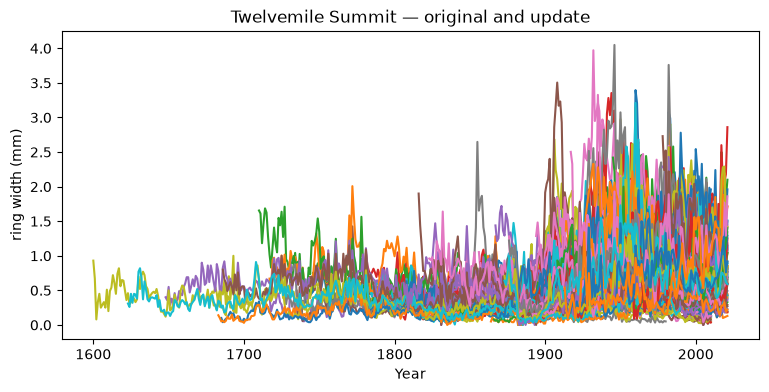

In [39]:
tms = dpl.readers(RWL + "TMScombined.rwl")
tms.plot(legend=False,figsize=(9, 4))
plt.xlabel("Year")
plt.ylabel("ring width (mm)")
plt.title("Twelvemile Summit — original and update")
plt.show()

### Non-ASCII series IDs are handled correctly

Series IDs containing non-ASCII characters are preserved as-is:

In [40]:
ru = dpl.readers(RWL + "russ301.rwl")
[c for c in ru.columns if any(ord(ch) > 127 for ch in c)][:6]

russ301.rwl successfully extracted as rwl file with 80 series covering the period from 1847 to 2018 (auto-detected 3 header lines)


['Áä89-06', 'Áä89-10', 'Áä89-12', 'Áä89-13', 'Áä89-14', 'Áä89-15']

### `readers` also imports CSV files

`readers` also reads year-indexed CSV ring-width files:

In [41]:
csv = dpl.readers(CSV + "ca533.csv")
csv

ca533.csv successfully extracted as csv file with 34 series covering the period from 626 to 1983


,CAM011,CAM021,CAM031,CAM032,CAM041,CAM042,CAM051,CAM061,CAM062,CAM071,...,CAM151,CAM152,CAM161,CAM162,CAM171,CAM172,CAM181,CAM191,CAM201,CAM211
Year,,,,,,,,,,,,,,,,,,,,,
626,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.17
627,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.13
628,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.14
629,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.19
630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1979,0.40,0.42,0.33,0.61,0.75,0.50,0.25,0.42,0.58,0.11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980,0.45,0.59,0.77,0.67,1.09,0.65,0.36,0.69,0.71,0.14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1981,0.48,0.57,0.69,0.55,0.76,0.56,0.32,0.64,0.51,0.27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Documentation

The complete documentation is available in the dplPy documentation here: https://opendendro.github.io/dplPy/reference/io/#readers